# 군집화

소속 집단의 정보가 없고 모르는 상태에서 비슷한 집단으로 묶는 비지도 학습  
입력 데이터를 바탕으로 예측 출력값을 만드는 목적 보다는, **데이터에서 의미를 파악하고 기준을 만드는 목적으로 사용**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster

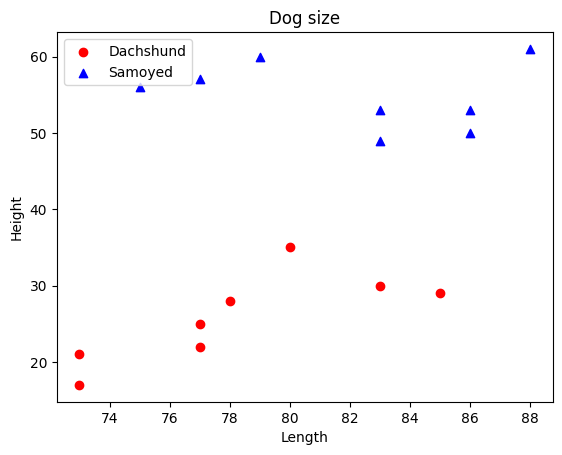

In [ ]:
# 닥스훈트 길이 & 높이
dach_lengh = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]

# 사모예드 길이 & 높이
samo_lengh = [75, 77, 86, 86, 79, 83, 83, 88]
samo_height = [56, 57, 50, 53, 60, 53, 49, 61]

dog_lengh = np.array(dach_lengh + samo_lengh)
dog_height = np.array(dach_height + samo_height)

dog_data = np.column_stack((dog_lengh, dog_height)) # [lengh, height] 구조로 합침

print(min(dog_lengh), max(dog_lengh))
print(min(dog_height), max(dog_height))

# 점 그래프로 표현
plt.scatter(dach_lengh, dach_height, c="red", label="Dachshund")
plt.scatter(samo_lengh, samo_height, c="blue", marker="^", label="Samoyed")

plt.xlabel("Length")
plt.ylabel("Height")
plt.title("Dog size")
plt.legend(loc="upper left")

plt.show()

## K-Means
k : 군집의 개수

### 모델 만들기

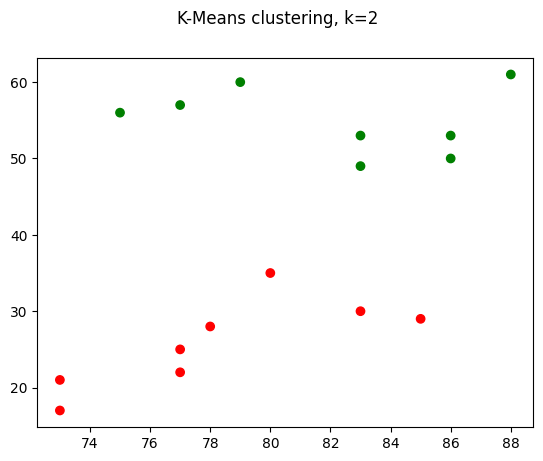

In [11]:
def kmeans_predict_plot(x, k):
    model = cluster.KMeans(n_clusters=k) # k개의 군집화 모델 객체 생성
    model.fit(x)    # x 데이터를 군집화 모델 학습
    labels = model.predict(x)   # x 데이터로 군집화 추론 (결과 : 각 데이터의 클래스)
    colors = np.array(["red", "green", "blue", "magenta"])
    plt.suptitle(f"K-Means clustering, k={k}")
    plt.scatter(x[:, 0], x[:, 1], c=colors[labels]) # 추론 결과를 산점도 그래프로 표시
    plt.show()
    
    return model

kmeans = kmeans_predict_plot(dog_data, k=2)

## 모델 저장

In [ ]:
from pathlib import Path
import pickle

MODEL_DIR = "model"
MODEL_FILE = MODEL_DIR + "/dog_model.pkl"

Path(MODEL_DIR).mkdir(exist_ok=True)

with open(MODEL_FILE, "wb") as f:
    pickle.dump(kmeans, f)

print("모델 저장 완료")

모델 저장 완료


### 모델 테스트

In [13]:
# 테스트용 닥스훈트 데이터
test_dach_length = [76, 82, 79]
test_dach_height = [24, 27, 23]

# 테스트용 사모예드 데이터
test_samo_length = [84, 87, 81]
test_samo_height = [55, 58, 52]

# 합치기
test_length = np.array(test_dach_length + test_samo_length)
test_height = np.array(test_dach_height + test_samo_height)

# y 데이터 (테스트용 입력 데이터)
test_data = np.column_stack((test_length, test_height))

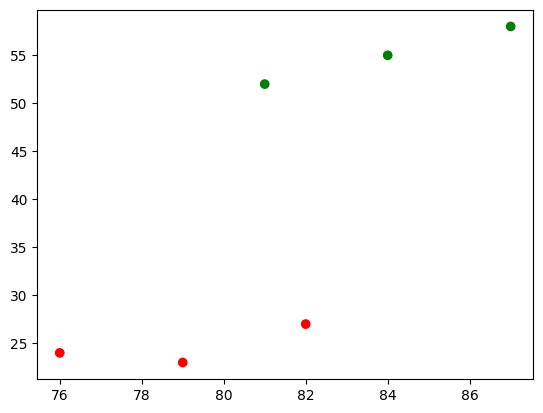

In [14]:
def model_predict_plot(model, x):
    labels = model.predict(x)
    colors = np.array(["red", "green", "blue", "magenta"])
    plt.scatter(x[:, 0], x[:, 1], c=colors[labels])
    plt.show()

model_predict_plot(kmeans, test_data)